In [1]:
# LEACE Visualization Notebook
#
# This notebook visualizes the effect of LEACE projection:
# 1. Embed sample texts before and after LEACE
# 2. Visualize embeddings with PCA
# 3. Train linear probes to measure demographic leakage
# 4. Calculate Amnesic Drop metric

import sys
sys.path.append('..')

In [2]:
# Import dependencies
import json
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from neuro_stylometry.phase_a_pipeline import PhaseAPipeline
from neuro_stylometry.factories.strategy_factory import StrategyFactory
from neuro_stylometry.pollution_guard.probe import compute_amnesic_drop
from neuro_stylometry.pollution_guard.concept_encoding import DemographicEncoder, extract_probe_labels
from neuro_stylometry.data_engine.schemas import get_demographic_columns
from neuro_stylometry.data_engine.dataset import SOBRDataset

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

# Initialize pipeline with strict YAML config authority
strategy = StrategyFactory.create_filter_strategy()
pipeline = PhaseAPipeline.from_yaml(strategy=strategy, mode="laptop")

# Access components via facade methods (new API)
embedder = pipeline.get_embedder()
leace = pipeline.get_leace()
detector = pipeline.get_detector()
masker = pipeline.get_masker()

print("=" * 60)
print("PHASE A PIPELINE CONFIGURATION")
print("=" * 60)
print(f"Embedder model: {embedder.model_name}")
print(f"Embedder device: {embedder.device}")
print(f"Embedder max_length: {embedder.max_length}")
print(f"LEACE embedding_dim: {leace.embedding_dim}")
print(f"LEACE regularization: {leace.regularization}")
print(f"LEACE force_cpu: {leace.force_cpu}")
print(f"GLiNER confidence_threshold: {detector.confidence_threshold}")
print("=" * 60)


c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\gliner\model.py:418: UserWarning: Resizing embeddings is not supported for bi-encoder models.
  instance.resize_embeddings()
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Mask token [MASK:BIRTH_YEAR] for birth_year_statement encoded as 9 tokens: [647, 41197, 1301, 294, 108527, 11623, 616, 97885, 592]
Mask token [MASK:COUNTRY] for country_of_origin encoded as 7 tokens: [647, 41197, 1301, 294, 98460, 22727, 592]
Mask token [MASK:DEMONYM] for dem

PHASE A PIPELINE CONFIGURATION
Embedder model: roberta-base
Embedder device: cuda
Embedder max_length: 512
LEACE embedding_dim: 768
LEACE regularization: 1e-05
LEACE force_cpu: True
GLiNER confidence_threshold: 0.6


## 1. Load Data and Apply GLiNER Masking

Load sample posts, apply GLiNER pollution detection and masking, then extract embeddings from **masked text**.

**Critical (Section 2 of LEACE Strategy Report):**
- LEACE must be computed on embeddings of **masked text** (`post_masked`), NOT raw text.
- This targets implicit stylometric leakage rather than explicit demographic tokens.
- The `FrozenEmbedder` must register the same typed mask tokens as `GLiNERDetector`.

In [3]:
# Load dataset (must use 'post_masked' from the Arrow dataset)
dataset_path = Path("../artifacts/data/sobr_laptop.arrow")
dataset = SOBRDataset(arrow_path=dataset_path, seed=int(pipeline.config["seed"]))
table = dataset.table
print(f"Loaded table with {len(table)} rows from: {dataset_path}")

if "post_masked" not in table.column_names:
    raise KeyError("Expected column 'post_masked' in SOBR Arrow dataset")

# Ensure we truly use post_masked; if any are missing, backfill via GLiNER -> typed masker
post_ids = table["post_id"].to_pylist()
posts_raw = table["post"].to_pylist()
posts_masked = table["post_masked"].to_pylist()

missing_masked_idx = [i for i, v in enumerate(posts_masked) if v is None]
print(f"post_masked missing count: {len(missing_masked_idx)}")

if len(missing_masked_idx) > 0:
    print("Backfilling missing post_masked entries via GLiNER masking...")
    raw_subset = [posts_raw[i] for i in missing_masked_idx]
    id_subset = [post_ids[i] for i in missing_masked_idx]
    gliner_batch_size = int(pipeline.config["gliner"]["batch_size"])
    entities_subset = detector.detect_spans_long(
        raw_subset,
        batch_size=gliner_batch_size,
        show_progress=True,
    )
    masked_subset, _ = masker.mask_batch(raw_subset, entities_subset, id_subset)
    for j, i in enumerate(missing_masked_idx):
        posts_masked[i] = masked_subset[j]
    print("Backfill complete.")

# Build joint multi-demographic concept matrix Z with missingness indicators (Strategy C)
demo_cols = get_demographic_columns()
demo_encoder = DemographicEncoder(demo_cols).fit(table)
concepts = torch.from_numpy(demo_encoder.transform(table))
print(f"Concept matrix shape: {concepts.shape} (Strategy C joint Z with missing indicators)")

# Quick label availability snapshot (NULLs are excluded from probing/metrics later)
avail = {c: int(table[c].null_count) for c in demo_cols}
print("Null counts per demographic (lower is better):")
print(avail)

# Embed MASKED texts (critical requirement)
print("\n" + "=" * 60)
print("EMBEDDING post_masked (NOT raw post)")
print("=" * 60)
encoder_batch_size = int(pipeline.config["encoder"]["batch_size"])
print(f"Embedding {len(posts_masked)} masked posts (batch_size={encoder_batch_size})...")
embeddings_before = embedder.embed_texts(posts_masked, batch_size=encoder_batch_size, show_progress=True)
embeddings_before = embeddings_before.detach().to("cpu", dtype=torch.float32)
print(f"Embeddings shape: {embeddings_before.shape} (moved to CPU)")

# Build a deterministic viz subset (keeps plots readable)
viz_size = min(2000, len(table))
rng = np.random.default_rng(int(pipeline.config["seed"]))
viz_indices_np = rng.choice(len(table), size=viz_size, replace=False).astype(np.int64)
viz_indices_t = torch.from_numpy(viz_indices_np)

table_viz = table.take(pa.array(viz_indices_np))
embeddings_before_viz = embeddings_before[viz_indices_t]
print(f"Viz subset: {len(table_viz)} rows")

Loaded table with 1255 rows from: ..\artifacts\data\sobr_laptop.arrow
post_masked missing count: 0
Concept matrix shape: torch.Size([1255, 29]) (Strategy C joint Z with missing indicators)
Null counts per demographic (lower is better):
{'birth_year': 1002, 'female': 963, 'nationality': 715, 'political_leaning': 1183, 'extrovert': 1075, 'sensing': 1149, 'feeling': 1070, 'judging': 1067}

EMBEDDING post_masked (NOT raw post)
Embedding 1255 masked posts (batch_size=32)...


Embedding texts: 100%|██████████| 40/40 [00:50<00:00,  1.25s/it]

Embeddings shape: torch.Size([1255, 768]) (moved to CPU)
Viz subset: 1255 rows


## 2. Compute LEACE Projection (Joint Space with Missing Indicators)

Compute projection matrix to remove *all* demographic information (all columns in `SOBR_SCHEMA` demographics list) as a single multi-dimensional concept $Z$.

**Strategy C (Section 3.2 of LEACE Strategy Report):**
- Joint Design Matrix $Z$ with Missingness Indicators handles sparse SOBR labels
- Uses `compute_projection_from_concepts` for General LEACE formulation:
$$ P = I - \Sigma_{XZ} \Sigma_{ZZ}^{-1} \Sigma_{ZX} \Sigma_{XX}^{-1} $$

Computing LEACE projection matrix from post_masked embeddings...
Projection matrix shape: torch.Size([768, 768])
Embeddings after projection: torch.Size([1255, 768])
Idempotence max|P^2-P|: 8.34e-07
Saved projection to: ..\artifacts\phase_a_notebook\projection_matrix.pt
Singular values: min=0.000, median=1.000, max=9.165


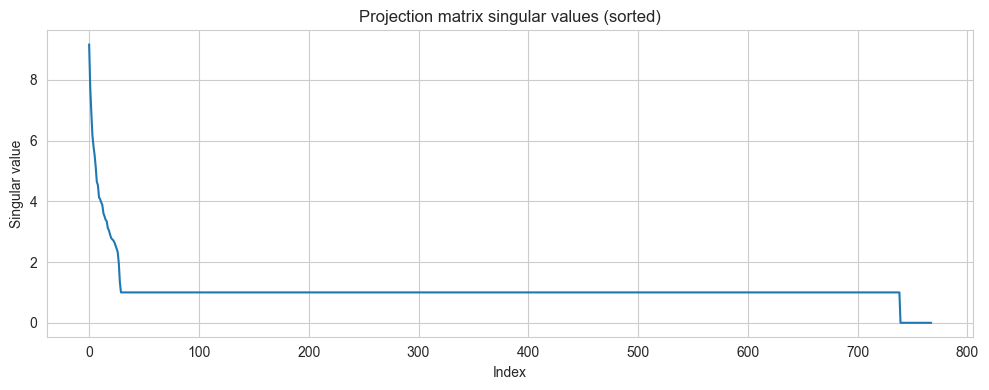

In [4]:
# Compute projection matrix (Strategy C: joint Z with missing indicators)
print("Computing LEACE projection matrix from post_masked embeddings...")
projection_matrix = leace.compute_projection_from_concepts(embeddings_before, concepts)

# Move to CPU for stable saving + downstream numpy/pandas ops
P = projection_matrix.detach().to("cpu", dtype=torch.float32)
X_before = embeddings_before.detach().to("cpu", dtype=torch.float32)

# Apply projection
embeddings_after = X_before @ P.T
print(f"Projection matrix shape: {P.shape}")
print(f"Embeddings after projection: {embeddings_after.shape}")

# Projection diagnostics (aligns with validator expectations)
idempotence_err = torch.abs(P @ P - P).max().item()
print(f"Idempotence max|P^2-P|: {idempotence_err:.2e}")

# Save projection matrix artifact
out_dir = Path("../artifacts/phase_a_notebook")
out_dir.mkdir(parents=True, exist_ok=True)
projection_path = out_dir / "projection_matrix.pt"
torch.save(P, projection_path)

meta = {
    "source_dataset": str(dataset_path),
    "uses_text_column": "post_masked",
    "strategy": "C (joint concept matrix Z with missingness indicators)",
    "n_rows": int(len(table)),
    "embedding_dim": int(X_before.shape[1]),
    "concept_dim": int(concepts.shape[1]),
    "seed": int(pipeline.config["seed"]),
    "idempotence_max_abs_P2_minus_P": float(idempotence_err),
}
(out_dir / "projection_matrix_meta.json").write_text(json.dumps(meta, indent=2))
print(f"Saved projection to: {projection_path}")

# Singular values as a rough measure of projection impact
sv = torch.linalg.svdvals(P)
sv_np = sv.cpu().numpy()
print(f"Singular values: min={sv_np.min():.3f}, median={np.median(sv_np):.3f}, max={sv_np.max():.3f}")

plt.figure(figsize=(10, 4))
plt.plot(np.sort(sv_np)[::-1])
plt.title("Projection matrix singular values (sorted)")
plt.xlabel("Index")
plt.ylabel("Singular value")
plt.tight_layout()
plt.show()

# Viz subset after projection
embeddings_after_viz = embeddings_after[viz_indices_t]

## 3. Visualize with PCA

Use PCA to visualize embeddings before and after LEACE projection.

PCA explained variance ratio (PC1..PC3): [0.16102318 0.10601051 0.05905776]
PCA cumulative variance (PC1..PC3): 32.61%
Plotting PCA before/after for 8 demographics...


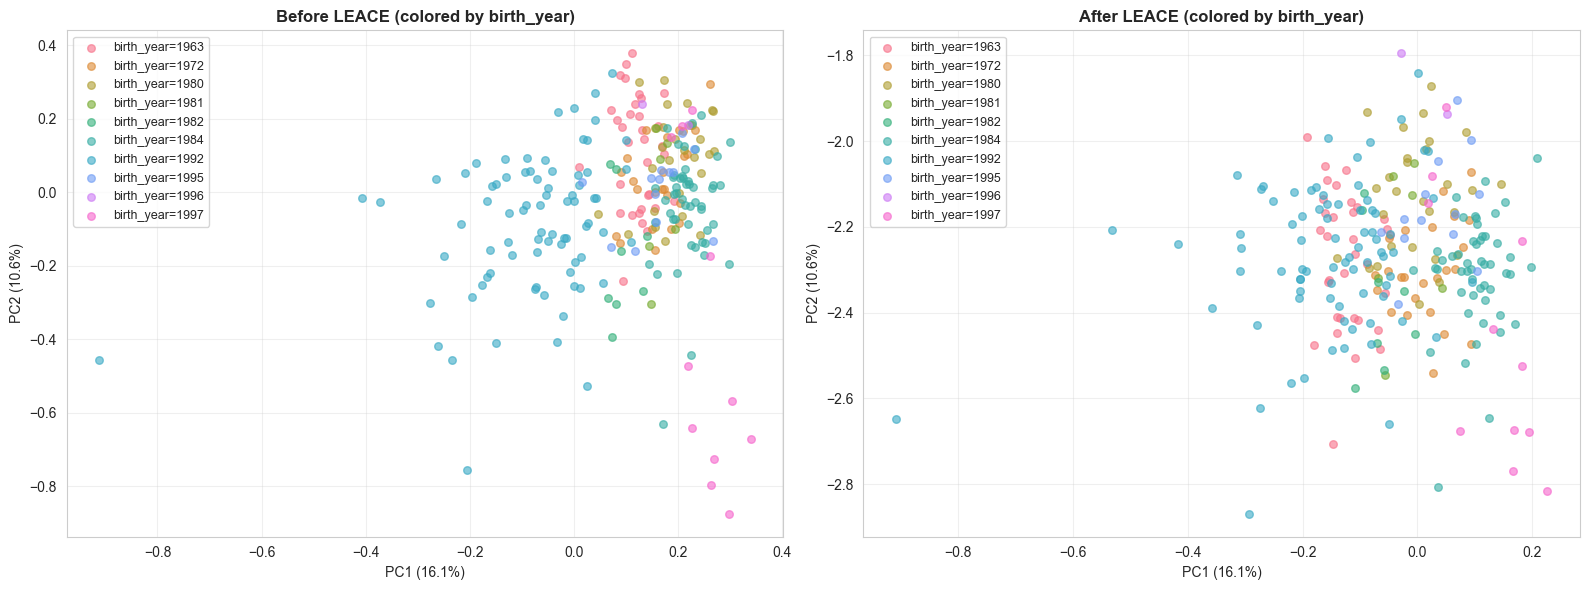

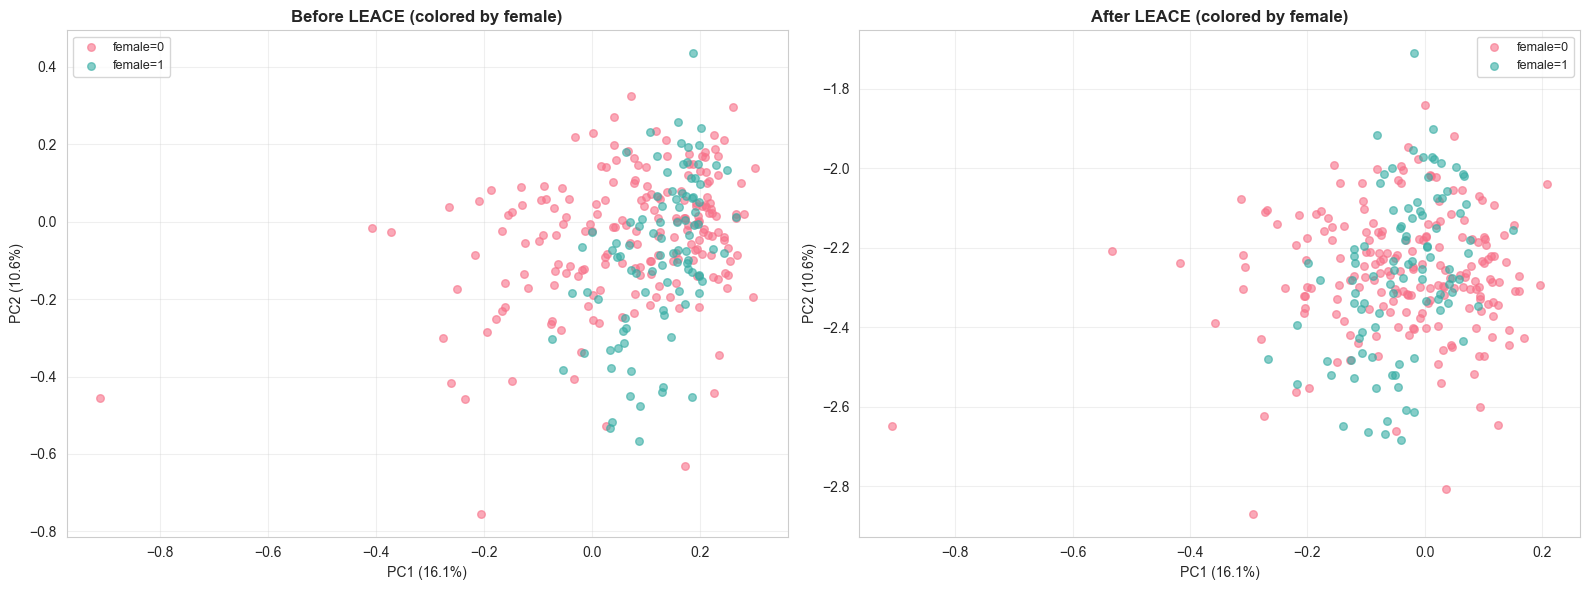

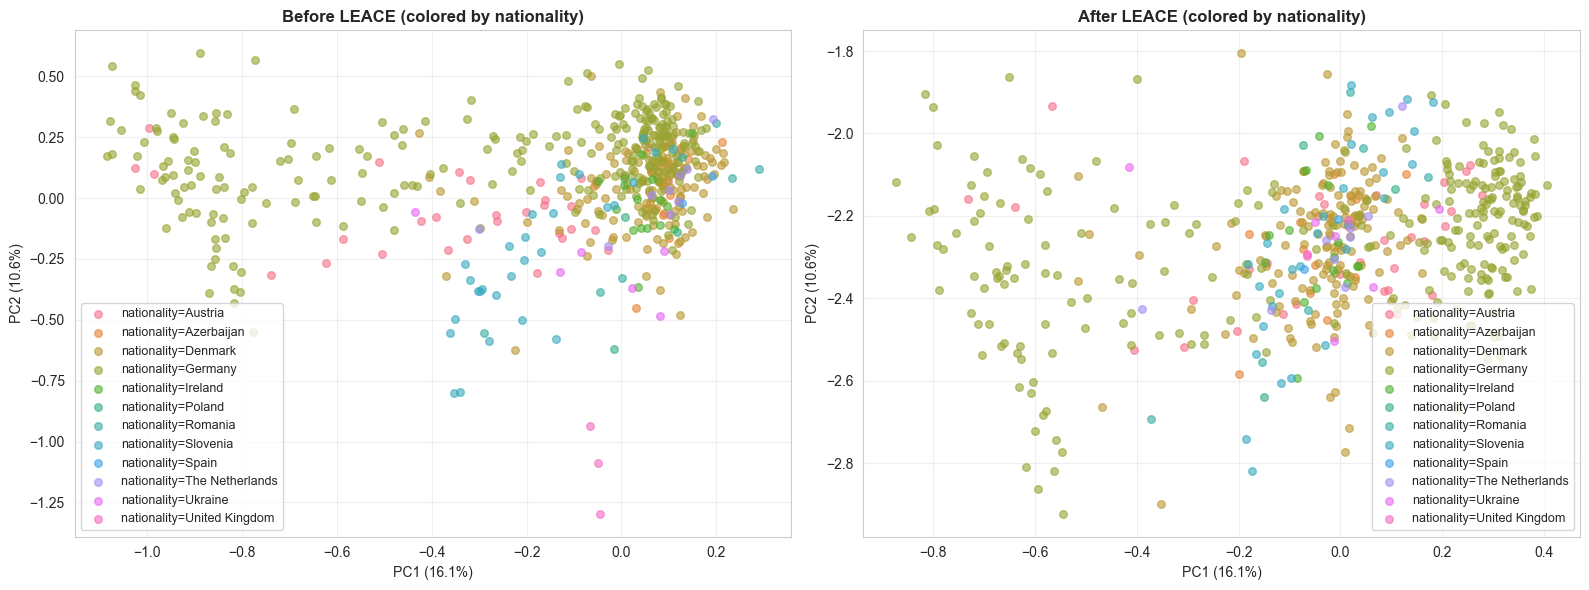

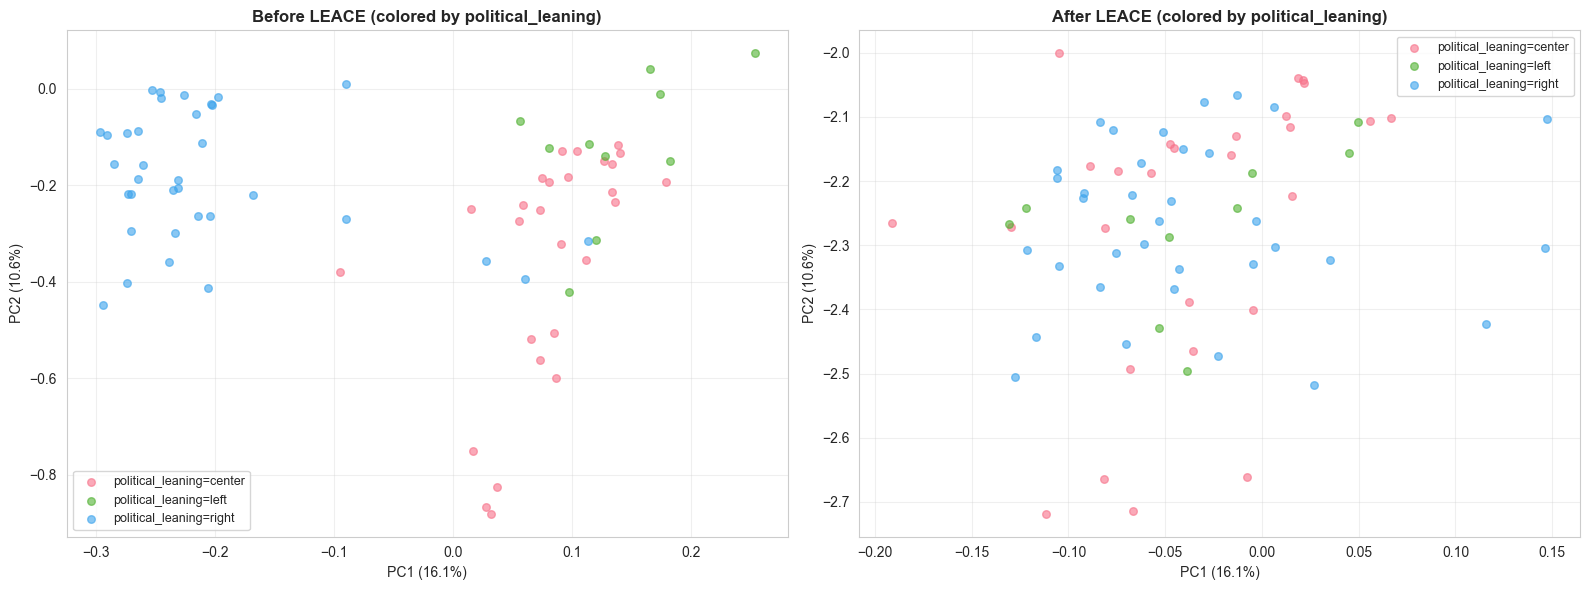

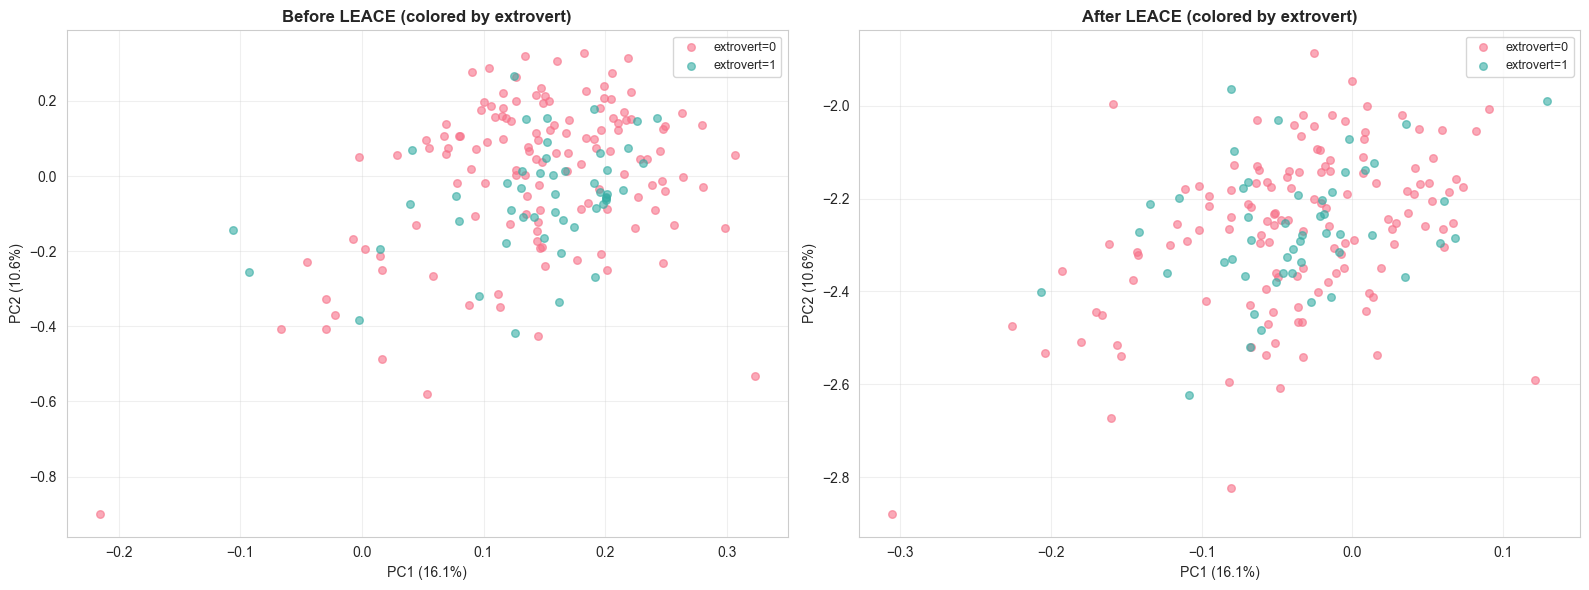

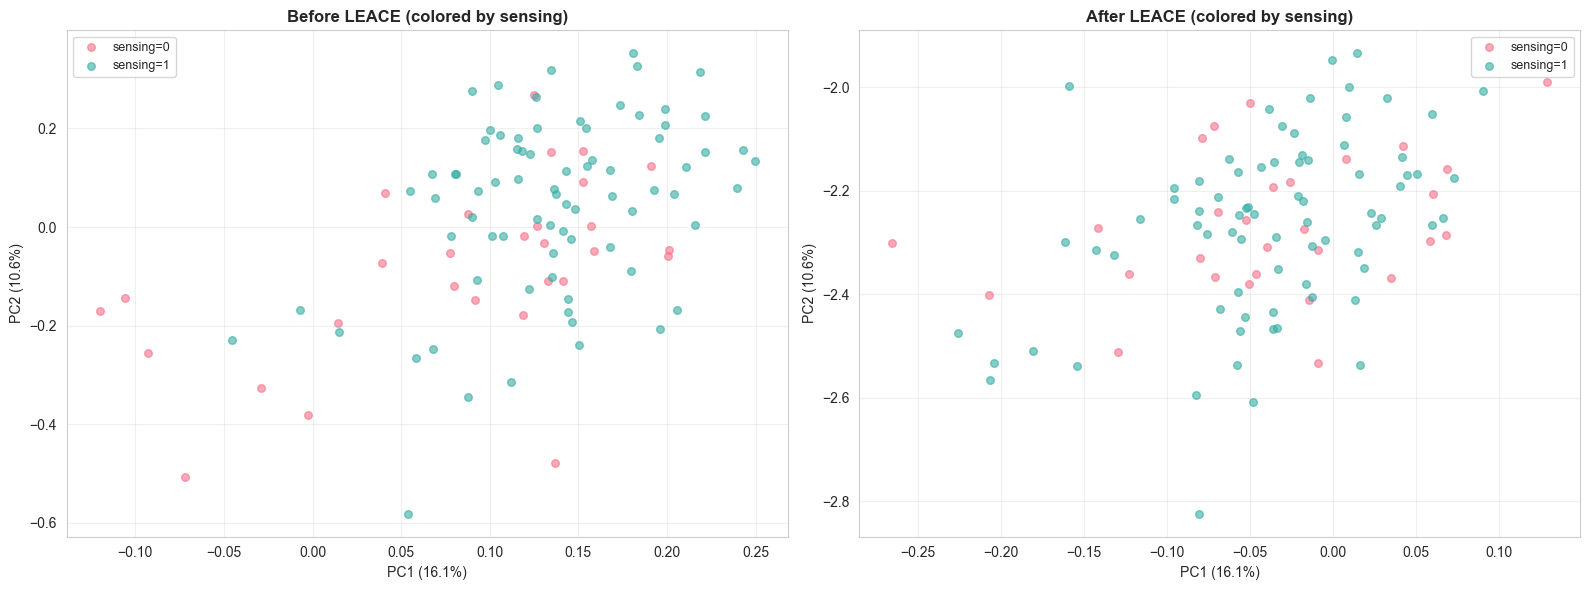

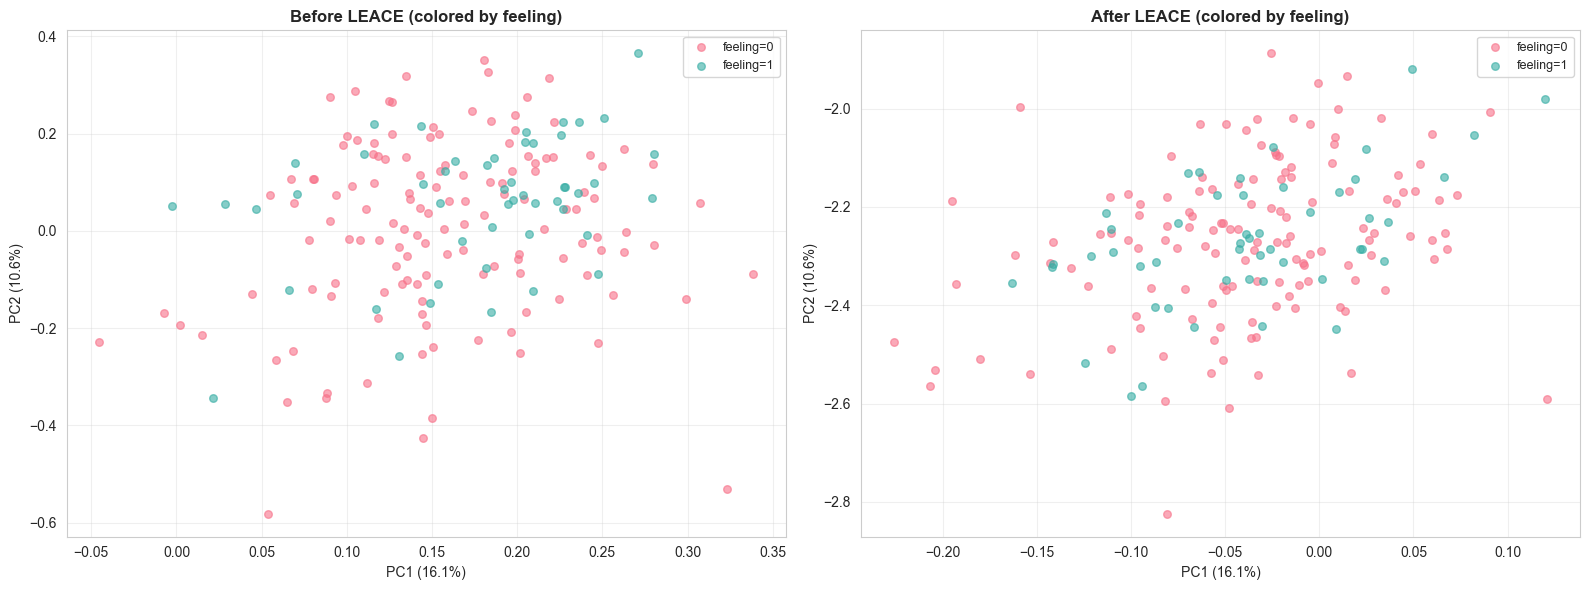

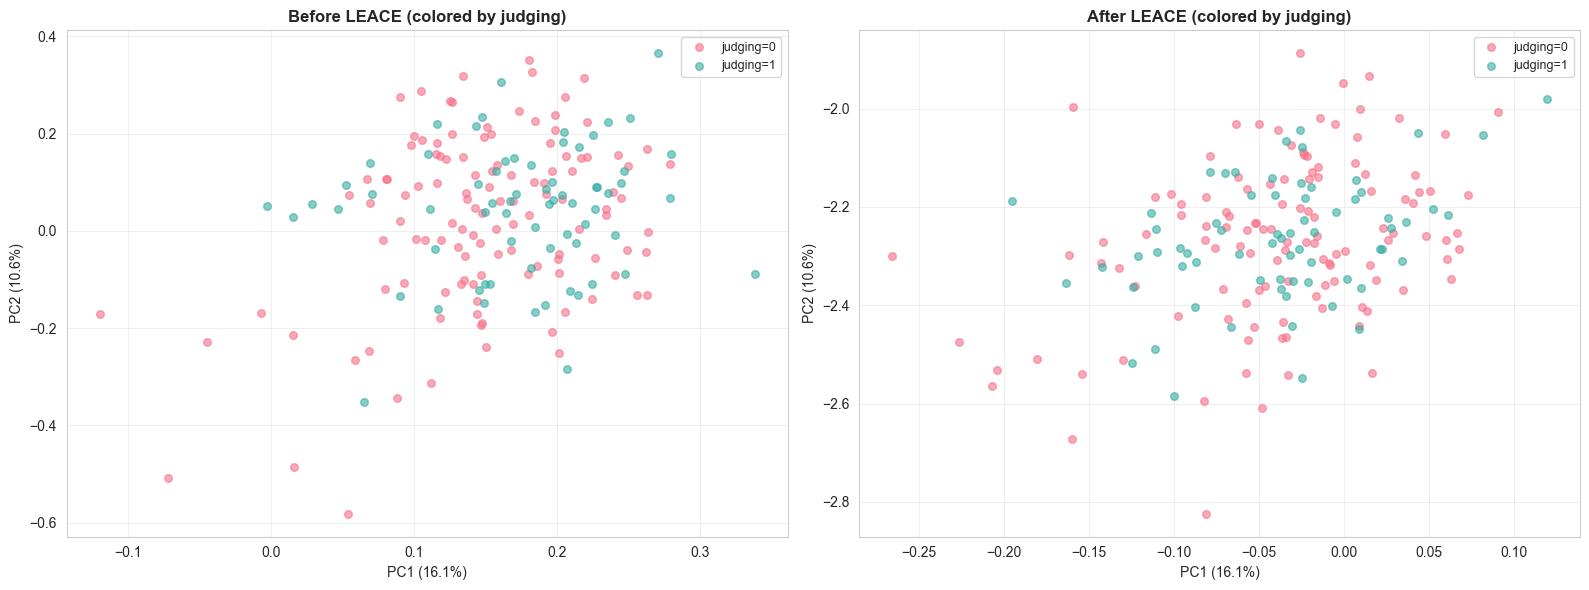

In [5]:
# PCA (fit on BEFORE, reuse transform on AFTER for comparable axes)
pca_model = PCA(n_components=3)
embeddings_before_np = embeddings_before_viz.cpu().numpy()
embeddings_after_np = embeddings_after_viz.cpu().numpy()

pca_before = pca_model.fit_transform(embeddings_before_np)
pca_after = pca_model.transform(embeddings_after_np)

print(f"PCA explained variance ratio (PC1..PC3): {pca_model.explained_variance_ratio_[:3]}")
print(f"PCA cumulative variance (PC1..PC3): {pca_model.explained_variance_ratio_[:3].sum():.2%}")

demo_cols = get_demographic_columns()
print(f"Plotting PCA before/after for {len(demo_cols)} demographics...")

for col in demo_cols:
    labels_int = extract_probe_labels(table_viz, col)
    valid_mask = labels_int >= 0
    n_valid = int(valid_mask.sum())
    if n_valid < 10:
        print(f"Skipping PCA plot for {col}: insufficient valid labels (n={n_valid})")
        continue

    # Optional: recover category names for string columns (keeps legends interpretable)
    series = table_viz[col].to_pandas()
    if series.dtype == object:
        cats = sorted(series.dropna().astype(str).unique().tolist())
        label_name = {i: cats[i] for i in range(len(cats))}
        legend_label = lambda i: f"{col}={label_name.get(i, str(i))}"
    else:
        legend_label = lambda i: f"{col}={i}"

    unique_labels = sorted(set(labels_int[valid_mask]))
    palette = sns.color_palette("husl", len(unique_labels))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # BEFORE
    for i, lab in enumerate(unique_labels):
        m = (labels_int == lab) & valid_mask
        axes[0].scatter(
            pca_before[m, 0],
            pca_before[m, 1],
            label=legend_label(lab),
            alpha=0.6,
            s=30,
            color=palette[i],
        )
    axes[0].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%})")
    axes[0].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%})")
    axes[0].set_title(f"Before LEACE (colored by {col})", fontweight="bold")
    axes[0].legend(markerscale=1, fontsize=9)
    axes[0].grid(alpha=0.3)

    # AFTER
    for i, lab in enumerate(unique_labels):
        m = (labels_int == lab) & valid_mask
        axes[1].scatter(
            pca_after[m, 0],
            pca_after[m, 1],
            label=legend_label(lab),
            alpha=0.6,
            s=30,
            color=palette[i],
        )
    axes[1].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%})")
    axes[1].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%})")
    axes[1].set_title(f"After LEACE (colored by {col})", fontweight="bold")
    axes[1].legend(markerscale=1, fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 3c. Embedding Space Metrics

Compute quantitative metrics comparing embedding spaces before and after LEACE.

EMBEDDING SPACE METRICS


,Metric,Before LEACE,After LEACE
0,Embedding norm (mean),10.896,4.771
1,Embedding norm (std),0.144,0.129
2,Cosine similarity (mean),0.996,0.987
3,Cosine similarity (std),0.002,0.006
4,Cosine similarity (median),0.997,0.988


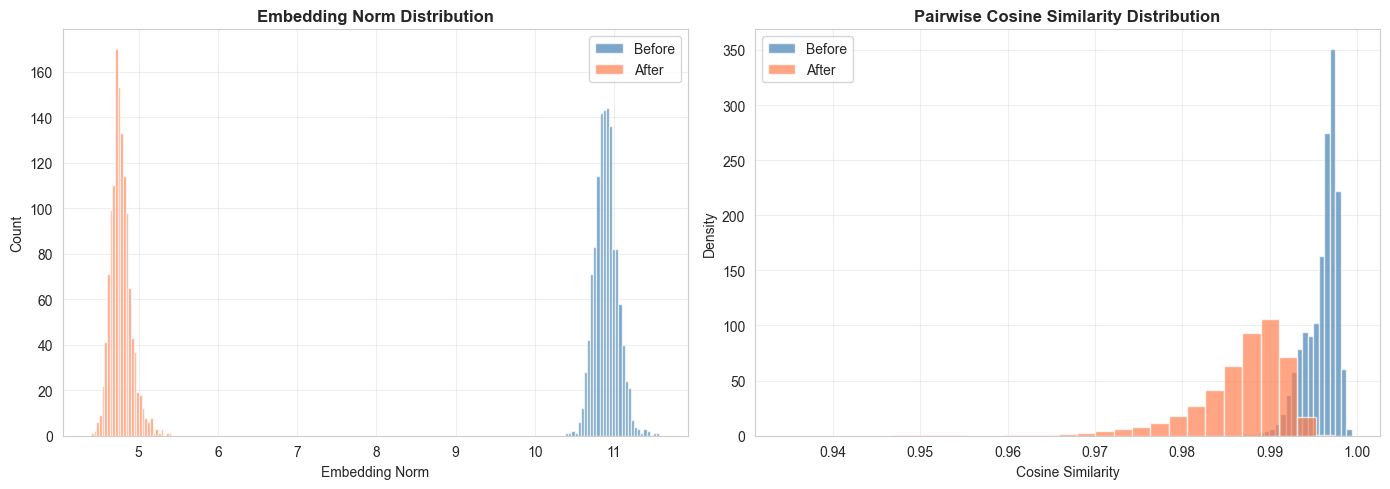


Note: LEACE may change embedding norms and similarity distributions.


In [6]:
# Compute embedding norms + pairwise cosine statistics (sampled)
Xb = embeddings_before.detach().to("cpu", dtype=torch.float32)
Xa = embeddings_after.detach().to("cpu", dtype=torch.float32)

norms_before = torch.norm(Xb, dim=1).numpy()
norms_after = torch.norm(Xa, dim=1).numpy()

# Compute pairwise cosine similarities (sample to avoid memory issues)
n_sample = min(500, len(Xb))
rng_metrics = np.random.default_rng(int(pipeline.config["seed"]))
sample_idx = rng_metrics.choice(len(Xb), n_sample, replace=False)

cos_sim_before = cosine_similarity(Xb[sample_idx].numpy())
cos_sim_after = cosine_similarity(Xa[sample_idx].numpy())

# Extract upper triangle (excluding diagonal)
triu_idx = np.triu_indices_from(cos_sim_before, k=1)
cos_sim_before_vals = cos_sim_before[triu_idx]
cos_sim_after_vals = cos_sim_after[triu_idx]

# Create metrics summary
metrics_summary = {
    "Metric": [
        "Embedding norm (mean)",
        "Embedding norm (std)",
        "Cosine similarity (mean)",
        "Cosine similarity (std)",
        "Cosine similarity (median)",
    ],
    "Before LEACE": [
        f"{norms_before.mean():.3f}",
        f"{norms_before.std():.3f}",
        f"{cos_sim_before_vals.mean():.3f}",
        f"{cos_sim_before_vals.std():.3f}",
        f"{np.median(cos_sim_before_vals):.3f}",
    ],
    "After LEACE": [
        f"{norms_after.mean():.3f}",
        f"{norms_after.std():.3f}",
        f"{cos_sim_after_vals.mean():.3f}",
        f"{cos_sim_after_vals.std():.3f}",
        f"{np.median(cos_sim_after_vals):.3f}",
    ],
}

metrics_df = pd.DataFrame(metrics_summary)
print("=" * 80)
print("EMBEDDING SPACE METRICS")
print("=" * 80)
display(metrics_df)
print("=" * 80)

# Plot norm distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(norms_before, bins=30, alpha=0.7, label="Before", color="steelblue")
axes[0].hist(norms_after, bins=30, alpha=0.7, label="After", color="coral")
axes[0].set_xlabel("Embedding Norm")
axes[0].set_ylabel("Count")
axes[0].set_title("Embedding Norm Distribution", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot cosine similarity distributions
axes[1].hist(cos_sim_before_vals, bins=30, alpha=0.7, label="Before", color="steelblue", density=True)
axes[1].hist(cos_sim_after_vals, bins=30, alpha=0.7, label="After", color="coral", density=True)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Density")
axes[1].set_title("Pairwise Cosine Similarity Distribution", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: LEACE may change embedding norms and similarity distributions.")

## 3b. Demographic-Score Scatter Matrices (Lower Triangle)

Instead of a scatter matrix over PCA components, we build **one scalar score per demographic** by projecting embeddings onto a demographic-specific direction (computed from class centroids).

- When comparing two *different* demographics ($x \neq y$), a simple scatter plot of these two demographic scores is more directly interpretable than using PCA components.
- On the diagonal ($x = y$), we plot a KDE of the score distribution split by classes (e.g., female=0 vs female=1).
- We only show the **lower triangle** to avoid redundant plots.

Demographic score axes available: ['birth_year', 'female', 'nationality', 'political_leaning', 'extrovert', 'sensing', 'feeling', 'judging']


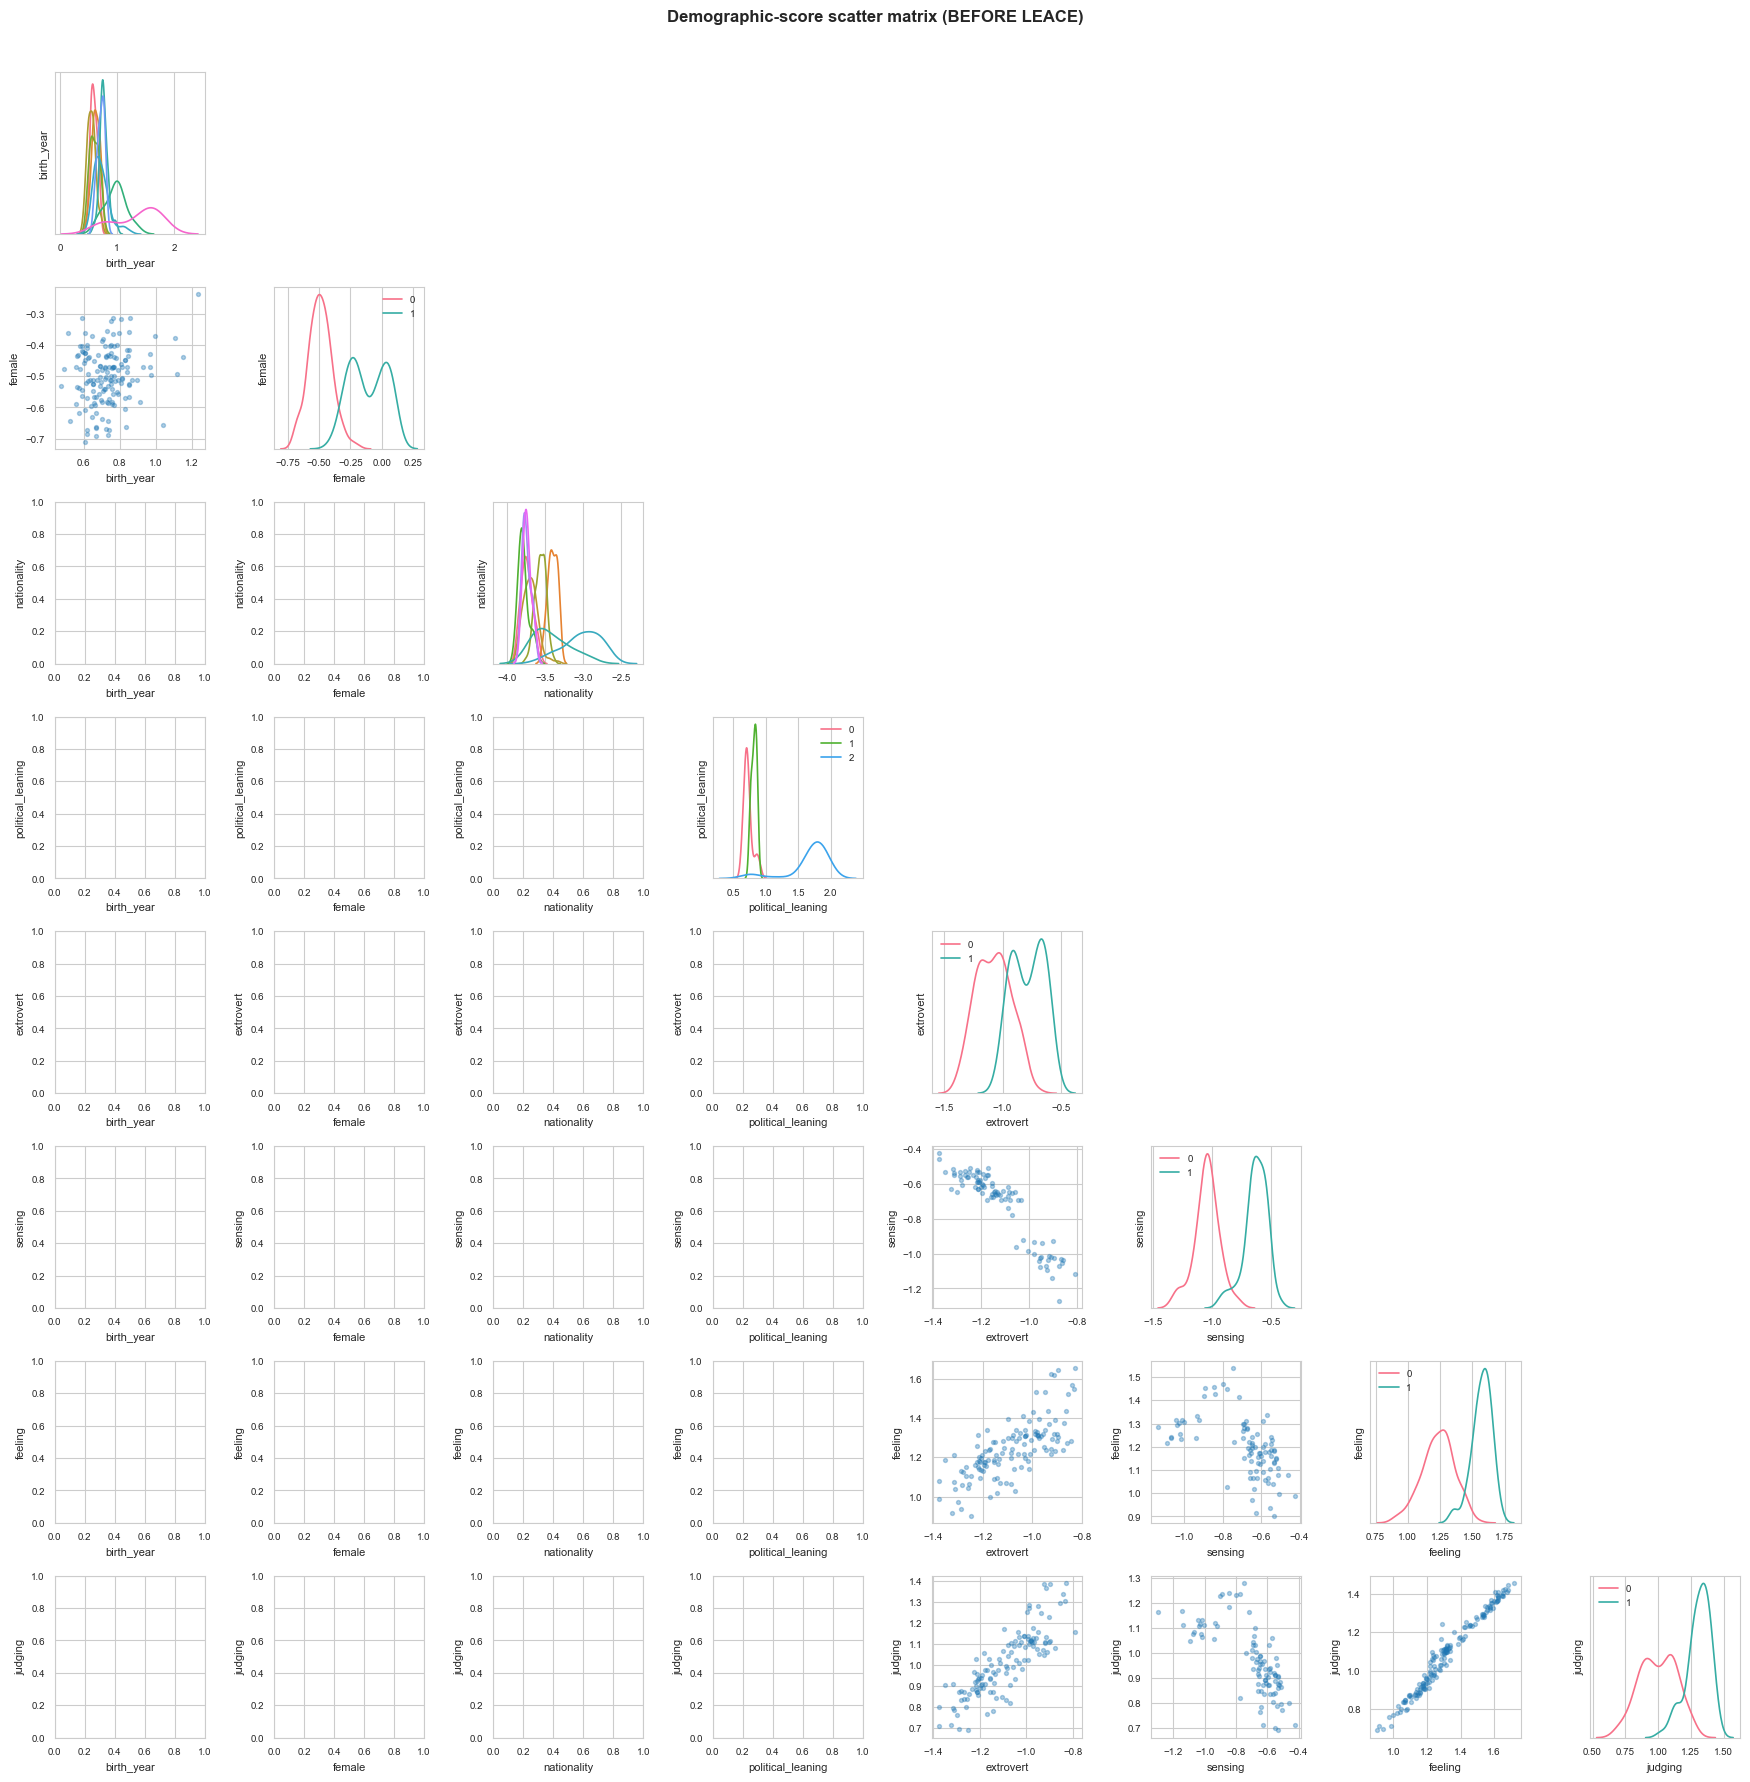

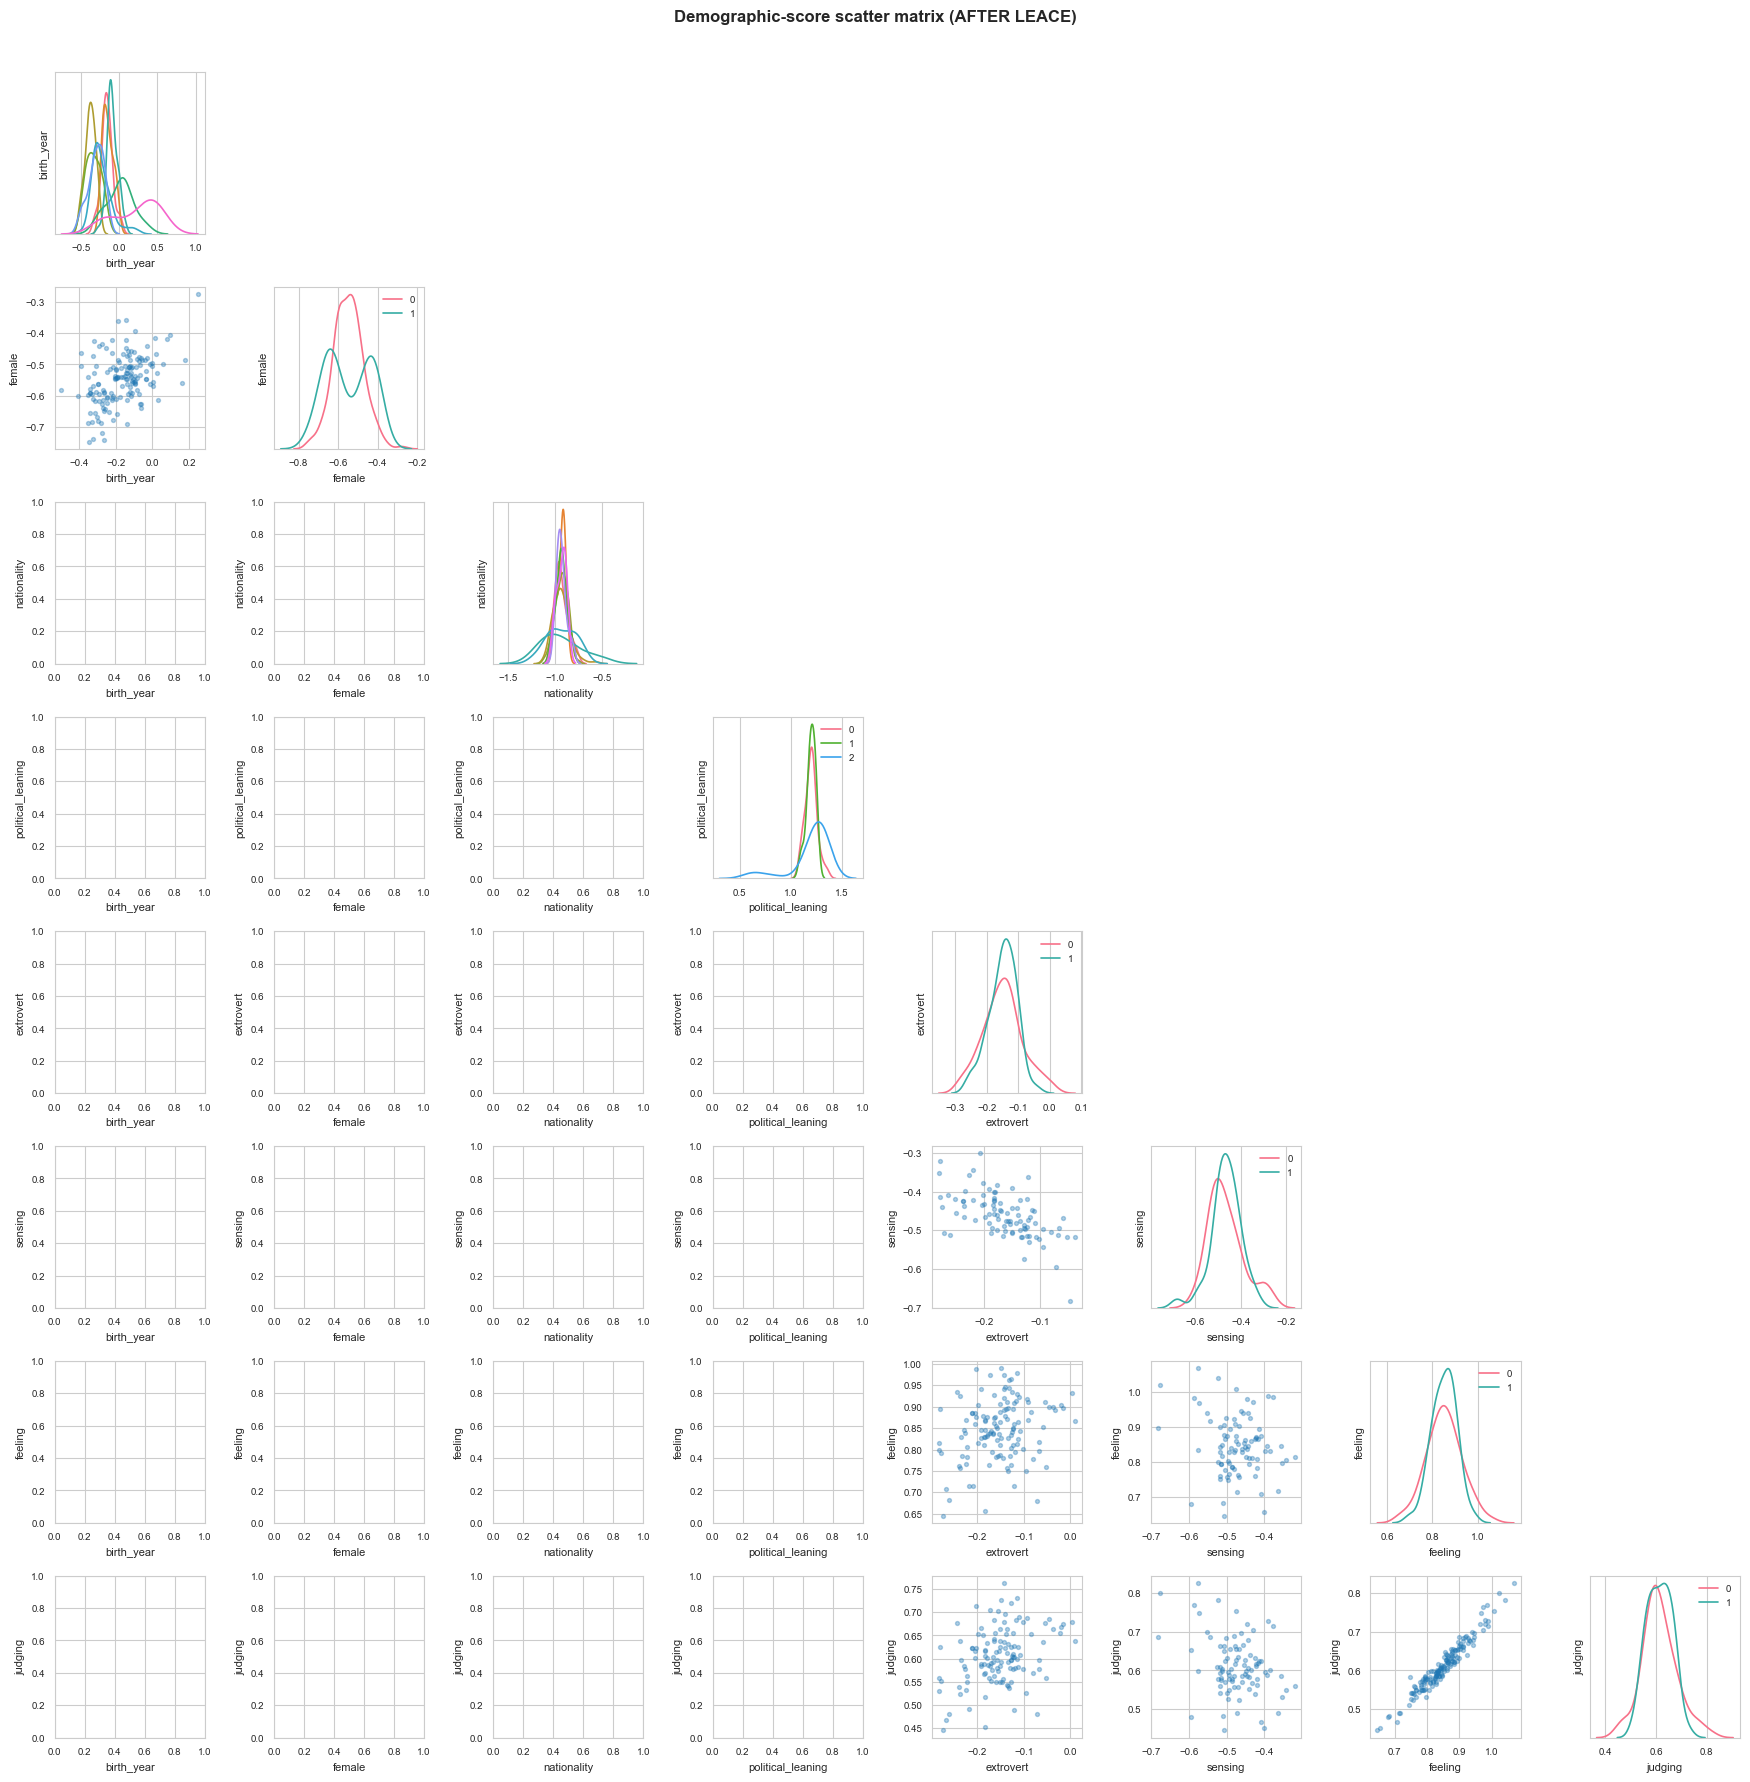

In [7]:
# Build demographic-specific 1D scores (axis encodes demographic)
demo_cols = get_demographic_columns()

X_before_full = embeddings_before.detach().to("cpu", dtype=torch.float32)
X_after_full = embeddings_after.detach().to("cpu", dtype=torch.float32)

def _compute_centroid_direction(X: torch.Tensor, labels: np.ndarray) -> torch.Tensor | None:
    valid = labels >= 0
    if valid.sum() < 10:
        return None
    y = labels[valid]
    classes = sorted(np.unique(y).tolist())
    if len(classes) < 2:
        return None

    idx_valid = np.where(valid)[0]
    centroids = []
    for c in classes:
        idx_c = idx_valid[labels[idx_valid] == c]
        if len(idx_c) < 5:
            continue
        centroids.append(X[idx_c].mean(dim=0))
    if len(centroids) < 2:
        return None
    C = torch.stack(centroids, dim=0)  # (n_classes, d)
    C = C - C.mean(dim=0, keepdim=True)

    if C.shape[0] == 2:
        direction = C[1] - C[0]
    else:
        # First principal direction of the class-centroid cloud
        # (right-singular vector of centroid matrix)
        _, _, Vh = torch.linalg.svd(C, full_matrices=False)
        direction = Vh[0]

    direction = direction / (torch.norm(direction) + 1e-12)
    return direction

# Compute directions from FULL data (more stable), then score the VIZ subset
directions = {}
labels_viz = {}
scores_before = {}
scores_after = {}

for col in demo_cols:
    labels_full = extract_probe_labels(table, col)
    d = _compute_centroid_direction(X_before_full, labels_full)
    if d is None:
        print(f"Skipping score direction for {col}: insufficient label diversity")
        continue
    directions[col] = d
    lv = extract_probe_labels(table_viz, col)
    labels_viz[col] = lv
    scores_before[col] = (embeddings_before_viz @ d).cpu().numpy()
    scores_after[col] = (embeddings_after_viz @ d).cpu().numpy()

demo_cols_scored = [c for c in demo_cols if c in directions]
print(f"Demographic score axes available: {demo_cols_scored}")

def _plot_lower_triangle(scores_by_demo: dict, labels_by_demo: dict, title: str) -> None:
    cols = list(scores_by_demo.keys())
    n = len(cols)
    if n == 0:
        print("No demographics available for scatter matrix.")
        return

    fig, axes = plt.subplots(n, n, figsize=(2.2 * n, 2.2 * n))
    fig.suptitle(title, y=1.01, fontweight="bold")

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.axis("off")
                continue

            col_i = cols[i]
            col_j = cols[j]
            si = scores_by_demo[col_i]
            sj = scores_by_demo[col_j]
            li = labels_by_demo[col_i]
            lj = labels_by_demo[col_j]

            if i == j:
                # Diagonal: KDE by class for this demographic
                valid = li >= 0
                if valid.sum() >= 10:
                    classes = sorted(set(li[valid]))
                    palette = sns.color_palette("husl", len(classes))
                    for k, c in enumerate(classes):
                        m = valid & (li == c)
                        if m.sum() < 5:
                            continue
                        sns.kdeplot(x=si[m], ax=ax, color=palette[k], label=str(c), linewidth=1.2)
                    ax.set_yticks([])
                    if len(classes) <= 6:
                        ax.legend(fontsize=7, frameon=False)
                ax.set_xlabel(col_j, fontsize=8)
                ax.set_ylabel(col_i, fontsize=8)
            else:
                # Lower triangle: scatter of two demographic scores (only where both labels exist)
                valid = (li >= 0) & (lj >= 0)
                if valid.sum() >= 10:
                    ax.scatter(sj[valid], si[valid], s=8, alpha=0.35)
                ax.set_xlabel(col_j, fontsize=8)
                ax.set_ylabel(col_i, fontsize=8)

            ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

_plot_lower_triangle(scores_before, labels_viz, "Demographic-score scatter matrix (BEFORE LEACE)")
_plot_lower_triangle(scores_after, labels_viz, "Demographic-score scatter matrix (AFTER LEACE)")

## 4. Compute Amnesic Drop

Train linear probes to measure demographic leakage before and after LEACE.

Computing Amnesic Drop metrics per demographic (ONLY non-missing labels)...



c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib

PROBE ACCURACY SUMMARY (MEAN ± STD OVER SEEDS)


c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,demographic,acc_before_mean,acc_before_std,acc_after_mean,acc_after_std,drop_mean,drop_std
4,extrovert,0.814815,0.034645,0.731481,0.013095,0.101303,0.023565
5,sensing,0.878788,0.056692,0.757576,0.021427,0.135617,0.038865
6,feeling,0.900901,0.033709,0.693694,0.083546,0.232278,0.063326
0,birth_year,0.849673,0.036973,0.620915,0.078974,0.269496,0.087694
1,female,0.966102,0.027678,0.683616,0.007990,0.292019,0.013924
7,judging,0.894737,0.037216,0.596491,0.062027,0.333631,0.058758
2,nationality,0.861111,0.013095,0.484568,0.021824,0.436766,0.033548
3,political_leaning,0.888889,0.062854,0.400000,0.094281,0.551587,0.090316



Detailed Per-Seed Results:


,demographic,seed,n_labeled,acc_before,acc_after,amnesic_drop
0,birth_year,0,253,0.823529,0.509804,0.380952
1,birth_year,1,253,0.823529,0.686275,0.166667
2,birth_year,2,253,0.901961,0.666667,0.260870
3,female,0,292,1.000000,0.694915,0.305085
4,female,1,292,0.932203,0.677966,0.272727
5,female,2,292,0.966102,0.677966,0.298246
6,nationality,0,540,0.879630,0.453704,0.484211
7,nationality,1,540,0.851852,0.500000,0.413043
8,nationality,2,540,0.851852,0.500000,0.413043
9,political_leaning,0,72,0.933333,0.533333,0.428571


C:\Users\20232788\AppData\Local\Temp\ipykernel_7552\3364121331.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(summary_df["demographic"], rotation=45, ha="right")


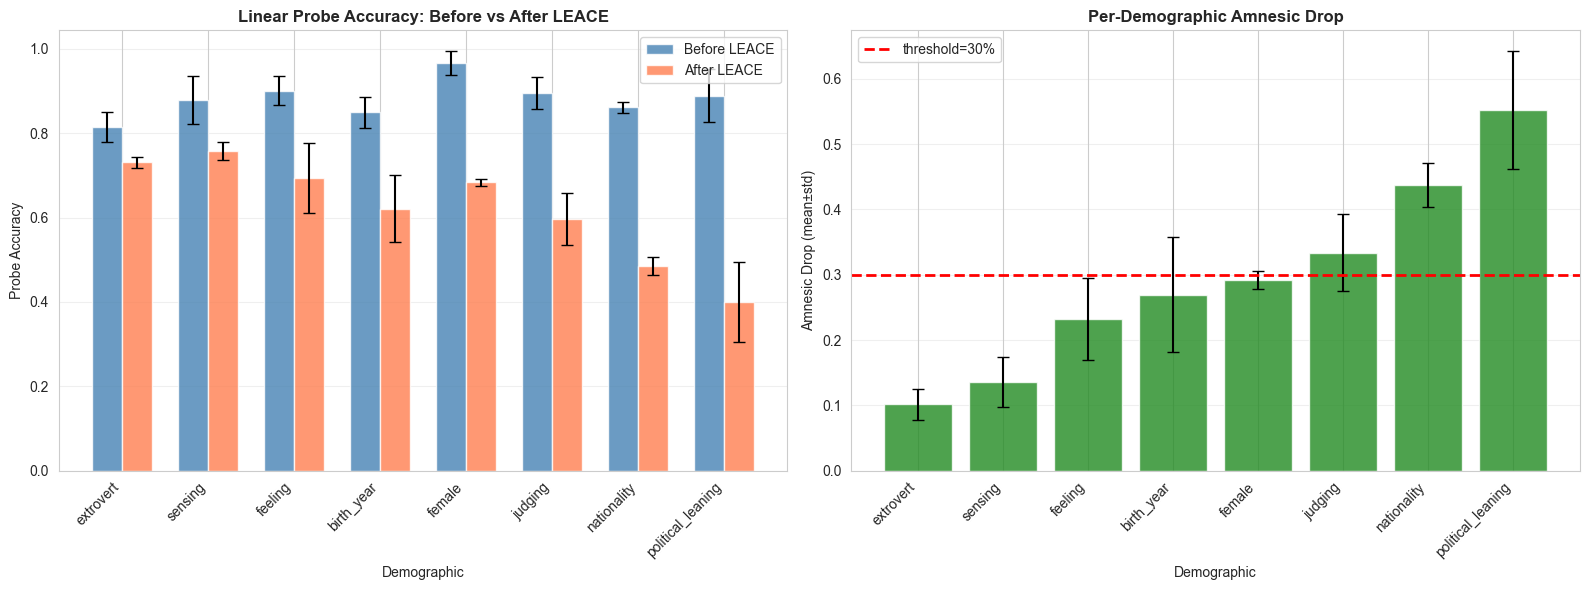


AMNESIC DROP SUMMARY (WEAKEST LINK)
Idempotence max|P^2-P|:           8.34e-07
Min mean drop across demographics: 10.1%
Target threshold:                  30.0%

✗ Target not met: Weakest demographic is 'extrovert' (10.1%)


In [8]:
# Compute amnesic drop per-demographic (repeat across multiple seeds for stability)
print("Computing Amnesic Drop metrics per demographic (ONLY non-missing labels)...\n")

seeds = [0, 1, 2]
demo_cols = get_demographic_columns()

X_before_full = embeddings_before.detach().to("cpu", dtype=torch.float32)
X_after_full = embeddings_after.detach().to("cpu", dtype=torch.float32)

results_by_col = {}
detailed_results = []

min_samples = 50  # minimum labeled examples to run a probe reliably

for col in demo_cols:
    labels_np = extract_probe_labels(table, col)
    valid = labels_np >= 0
    n_valid = int(valid.sum())
    if n_valid < min_samples:
        print(f"Skipping {col}: insufficient valid labels ({n_valid} < {min_samples})")
        continue

    # Restrict to only labeled rows (strictly satisfies: probes only computed on non-NaN labels)
    Xb = X_before_full[valid]
    Xa = X_after_full[valid]
    y = torch.tensor(labels_np[valid], dtype=torch.long)

    col_results = []
    for s in seeds:
        acc_before, acc_after, amnesic_drop = compute_amnesic_drop(
            embeddings_before=Xb,
            embeddings_after=Xa,
            labels=y,
            train_split=float(pipeline.config["probe"]["train_split"]),
            random_state=s,
        )
        col_results.append((acc_before, acc_after, amnesic_drop))
        detailed_results.append({
            "demographic": col,
            "seed": s,
            "n_labeled": int(n_valid),
            "acc_before": float(acc_before),
            "acc_after": float(acc_after),
            "amnesic_drop": float(amnesic_drop),
        })

    results_by_col[col] = col_results

# Aggregate summary
summary = []
for col, col_results in results_by_col.items():
    acc_before_vals = np.array([r[0] for r in col_results], dtype=float)
    acc_after_vals = np.array([r[1] for r in col_results], dtype=float)
    drop_vals = np.array([r[2] for r in col_results], dtype=float)
    summary.append({
        "demographic": col,
        "acc_before_mean": float(acc_before_vals.mean()),
        "acc_before_std": float(acc_before_vals.std(ddof=0)),
        "acc_after_mean": float(acc_after_vals.mean()),
        "acc_after_std": float(acc_after_vals.std(ddof=0)),
        "drop_mean": float(drop_vals.mean()),
        "drop_std": float(drop_vals.std(ddof=0)),
    })

summary_df = pd.DataFrame(summary).sort_values("drop_mean", ascending=True)

print("=" * 100)
print("PROBE ACCURACY SUMMARY (MEAN ± STD OVER SEEDS)")
print("=" * 100)
display(summary_df)
print("=" * 100)

# Detailed results table
detailed_df = pd.DataFrame(detailed_results)
print("\nDetailed Per-Seed Results:")
display(detailed_df.head(15))

# Weakest-link metric
min_drop = float(summary_df["drop_mean"].min()) if len(summary_df) else 0.0
threshold = float(pipeline.config["probe"]["amnesic_drop_threshold"])

# Plot accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot before/after accuracies
x = np.arange(len(summary_df))
width = 0.35
axes[0].bar(x - width/2, summary_df["acc_before_mean"], width,
            yerr=summary_df["acc_before_std"], label="Before LEACE",
            alpha=0.8, capsize=4, color="steelblue")
axes[0].bar(x + width/2, summary_df["acc_after_mean"], width,
            yerr=summary_df["acc_after_std"], label="After LEACE",
            alpha=0.8, capsize=4, color="coral")
axes[0].set_ylabel("Probe Accuracy")
axes[0].set_xlabel("Demographic")
axes[0].set_title("Linear Probe Accuracy: Before vs After LEACE", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df["demographic"], rotation=45, ha="right")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# Plot amnesic drops
axes[1].bar(summary_df["demographic"], summary_df["drop_mean"],
            yerr=summary_df["drop_std"], capsize=4, alpha=0.8, color="forestgreen")
axes[1].axhline(threshold, color="red", linestyle="--", linewidth=2,
                label=f"threshold={threshold:.0%}")
axes[1].set_ylabel("Amnesic Drop (mean±std)")
axes[1].set_xlabel("Demographic")
axes[1].set_title("Per-Demographic Amnesic Drop", fontweight="bold")
axes[1].set_xticklabels(summary_df["demographic"], rotation=45, ha="right")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "=" * 80)
print("AMNESIC DROP SUMMARY (WEAKEST LINK)")
print("=" * 80)
print(f"Idempotence max|P^2-P|:           {idempotence_err:.2e}")
print(f"Min mean drop across demographics: {min_drop:.1%}")
print(f"Target threshold:                  {threshold:.1%}")
print()
if min_drop >= threshold:
    print("✓ Target achieved: All demographics exceed threshold")
else:
    weakest = summary_df.iloc[0]
    print(f"✗ Target not met: Weakest demographic is '{weakest['demographic']}' ({weakest['drop_mean']:.1%})")
print("=" * 80)

## 5. Cross-Demographic Confusion Analysis

Analyze if LEACE reduces cross-demographic classification patterns.

c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Lo

Cross-demographic probe set: ['birth_year', 'female', 'nationality', 'political_leaning', 'extrovert', 'sensing', 'feeling', 'judging']


c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib


Cross-demographic probe accuracy matrices computed.


c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,birth_year,female,nationality,political_leaning,extrovert,sensing,feeling,judging
birth_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
female,NaN,0.966102,NaN,NaN,NaN,NaN,NaN,NaN
nationality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
political_leaning,NaN,NaN,NaN,0.888889,NaN,NaN,NaN,NaN
extrovert,NaN,NaN,NaN,NaN,0.814815,0.789474,0.935897,0.893333
sensing,NaN,NaN,NaN,NaN,0.877193,0.878788,0.907407,0.877193
feeling,NaN,NaN,NaN,NaN,0.871795,NaN,0.900901,0.885417
judging,NaN,NaN,NaN,NaN,0.853333,NaN,0.885417,0.894737


,birth_year,female,nationality,political_leaning,extrovert,sensing,feeling,judging
birth_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
female,NaN,0.683616,NaN,NaN,NaN,NaN,NaN,NaN
nationality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
political_leaning,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN
extrovert,NaN,NaN,NaN,NaN,0.731481,0.789474,0.935897,0.893333
sensing,NaN,NaN,NaN,NaN,0.771930,0.757576,0.907407,0.877193
feeling,NaN,NaN,NaN,NaN,0.871795,NaN,0.693694,0.729167
judging,NaN,NaN,NaN,NaN,0.853333,NaN,0.697917,0.596491


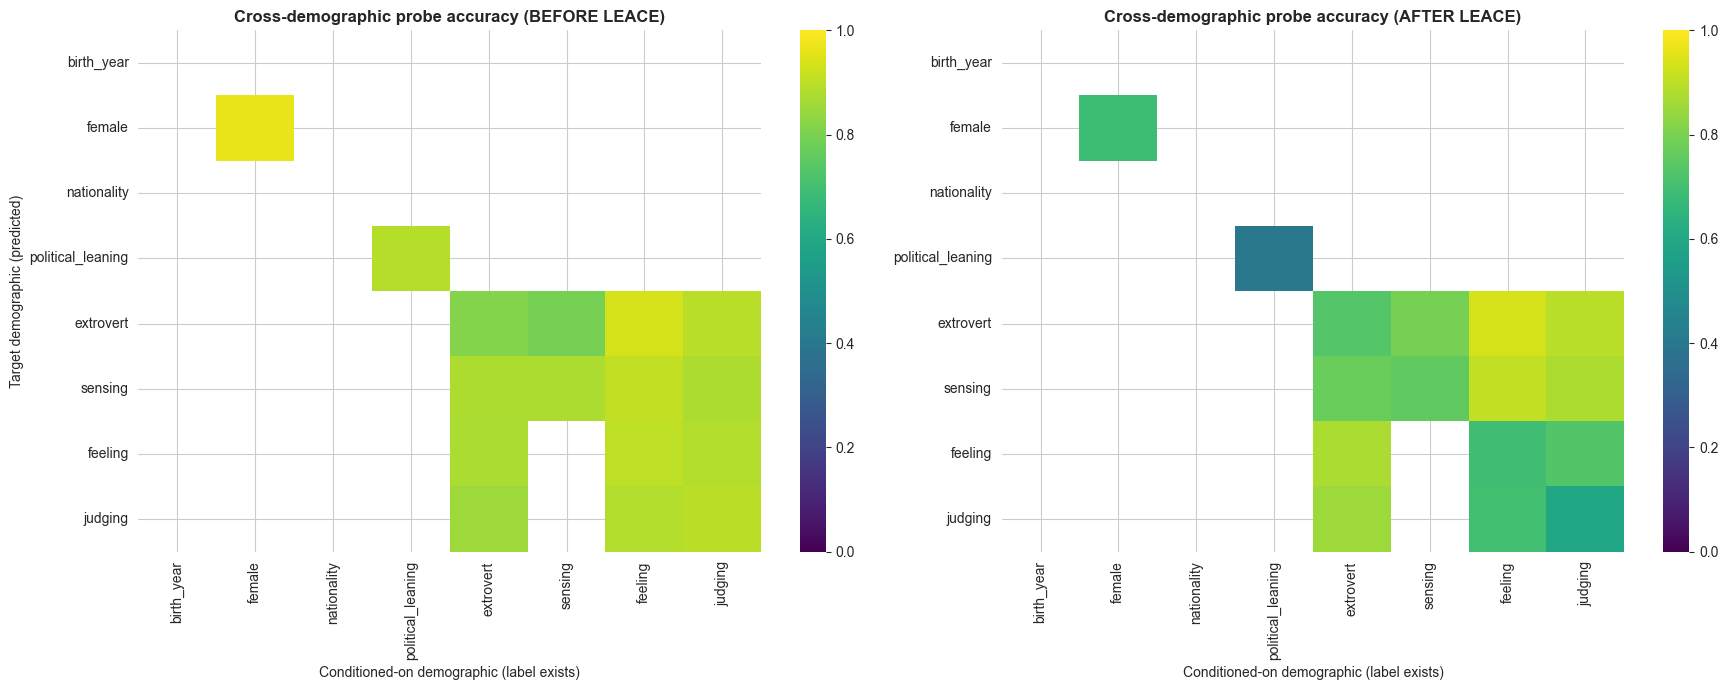

In [10]:
# Cross-demographic pair probing: for each (target, conditioned-on) pair,
# train a probe for the target using ONLY rows where both labels exist.
# Then visualize the resulting accuracies as before/after heatmaps.
import warnings

demo_list = list(results_by_col.keys())
print(f"Cross-demographic probe set: {demo_list}")

X_before_full = embeddings_before.detach().to("cpu", dtype=torch.float32)
X_after_full = embeddings_after.detach().to("cpu", dtype=torch.float32)

pair_min_samples = 50
seeds = [0, 1, 2]

acc_before_mat = pd.DataFrame(index=demo_list, columns=demo_list, dtype=float)
acc_after_mat = pd.DataFrame(index=demo_list, columns=demo_list, dtype=float)

for target in demo_list:
    y_all = extract_probe_labels(table, target)
    valid_y = y_all >= 0

    for cond in demo_list:
        z_all = extract_probe_labels(table, cond)
        valid_z = z_all >= 0

        mask = valid_y & valid_z
        n = int(mask.sum())
        if n < pair_min_samples:
            acc_before_mat.loc[target, cond] = np.nan
            acc_after_mat.loc[target, cond] = np.nan
            continue

        Xb = X_before_full[mask]
        Xa = X_after_full[mask]
        y = torch.tensor(y_all[mask], dtype=torch.long)

        # Require at least two classes and a minimum count per class to reliably train a probe.
        unique, counts = np.unique(y.numpy(), return_counts=True)
        if len(unique) < 2 or counts.min() < 5:
            # Not enough label diversity / per-class examples; skip this pair
            acc_before_mat.loc[target, cond] = np.nan
            acc_after_mat.loc[target, cond] = np.nan
            continue

        acc_b = []
        acc_a = []
        for s in seeds:
            try:
                a_b, a_a, _ = compute_amnesic_drop(
                    embeddings_before=Xb,
                    embeddings_after=Xa,
                    labels=y,
                    train_split=float(pipeline.config["probe"]["train_split"]),
                    random_state=s,
                )
            except ValueError as e:
                # Probe could not be trained for this split (e.g., degenerate label split).
                warnings.warn(f"Skipping pair ({target}, {cond}) due to training error: {e}")
                acc_b = []
                acc_a = []
                break
            acc_b.append(float(a_b))
            acc_a.append(float(a_a))

        if len(acc_b) == 0:
            acc_before_mat.loc[target, cond] = np.nan
            acc_after_mat.loc[target, cond] = np.nan
            continue

        acc_before_mat.loc[target, cond] = float(np.mean(acc_b))
        acc_after_mat.loc[target, cond] = float(np.mean(acc_a))

print("\nCross-demographic probe accuracy matrices computed.")
display(acc_before_mat)
display(acc_after_mat)

# Plot as correlation-style heatmaps (before vs after)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    acc_before_mat,
    ax=axes[0],
    vmin=0.0,
    vmax=1.0,
    cmap="viridis",
    annot=False,
    cbar=True,
)
axes[0].set_title("Cross-demographic probe accuracy (BEFORE LEACE)", fontweight="bold")
axes[0].set_xlabel("Conditioned-on demographic (label exists)")
axes[0].set_ylabel("Target demographic (predicted)")

sns.heatmap(
    acc_after_mat,
    ax=axes[1],
    vmin=0.0,
    vmax=1.0,
    cmap="viridis",
    annot=False,
    cbar=True,
)
axes[1].set_title("Cross-demographic probe accuracy (AFTER LEACE)", fontweight="bold")
axes[1].set_xlabel("Conditioned-on demographic (label exists)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()